# Brownfield/Surplus Interconnection BESS Optimization

Optimize BESS size and charging mode for an existing solar asset at a fixed POI limit.

| Cell | Content |
|------|---------|
| 1 | Load DAM price curve |
| 2 | Configuration |
| 3 | Imports + helpers |
| 4 | Simulation — 75 cases (25 sizes × 3 modes) |
| 5 | Save CSV + validation |
| 6 | Chart 1 — IRR heatmap 4-panel |
| 7 | Chart 2 — Revenue waterfall |
| 8 | Chart 3 — Price vs dispatch scatter |
| 9 | Interactive dashboard |

> Site: Scurry County TX | 300 MWac existing solar | 300 MW POI shared

In [1]:
import pandas as pd
from pathlib import Path

PRICE_CSV = Path('../../pvsamlab/data/DAMPriceExample.csv')
hourly_prices = pd.read_csv(PRICE_CSV, header=None).iloc[:, 0].tolist()
assert len(hourly_prices) == 8760, f"Expected 8760, got {len(hourly_prices)}"
print(f"Price range: ${min(hourly_prices):.2f} - ${max(hourly_prices):.2f}/MWh")
print(f"Avg price:   ${sum(hourly_prices)/len(hourly_prices):.2f}/MWh")

Price range: $-25.00 - $283.34/MWh
Avg price:   $43.99/MWh


In [2]:
# ── Existing asset ────────────────────────────────────────────────────────────
EXISTING_SOLAR_KWAC = 300_000
POI_LIMIT_KW        = 300_000
SOLAR_DCAC          = 1.35
SITE_LAT            = 33.0278
SITE_LON            = -100.0814
MET_YEAR            = '2017'

# ── BESS sizing matrix ────────────────────────────────────────────────────────
POWER_MW_LIST    = [50, 75, 100, 125, 150]
DURATION_HR_LIST = [1, 2, 4, 6, 8]

# ── Charging modes ────────────────────────────────────────────────────────────
CHARGING_MODES = {
    'solar_only':   {'can_gridcharge': 0, 'can_solar_charge': 1,
                     'label': 'Solar charge only'},
    'grid_only':    {'can_gridcharge': 1, 'can_solar_charge': 0,
                     'label': 'Grid charge only'},
    'unrestricted': {'can_gridcharge': 1, 'can_solar_charge': 1,
                     'label': 'Solar + grid charge'},
}

# ── Financial defaults ────────────────────────────────────────────────────────
CAPACITY_PAYMENT_KW_YR = 80.0
ANCILLARY_KW_YR        = 15.0
BESS_CAPEX_KWH         = 250.0
BESS_CAPEX_KW          = 150.0
BESS_EPC_MULTIPLIER    = 1.35   # BOS + installation + commissioning (equipment × 1.35 = all-in)
OPEX_KWH_YR            = 8.0
DISCOUNT_RATE          = 8.0

# ── Runtime ───────────────────────────────────────────────────────────────────
NUM_WORKERS = 4
LOAD_KW     = 200_000    # dispatch signal load (self_cons fallback)

In [3]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path('.').resolve().parent.parent))
sys.path.insert(0, str(pathlib.Path('.').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from tqdm.notebook import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

from pvsamlab import (
    Battery, BessDispatch, PvBessSystem, TrackingMode,
    Financial, compute_lcos,
)
from pvsamlab.financial import compute_irr, compute_npv
from pvsamlab.system import generate_pysam_inputs, process_outputs
from pvsamlab.battery import process_bess_outputs

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', font_scale=0.9)

_HERE  = pathlib.Path('.')
DT_IDX = pd.date_range('2017-01-01', periods=8760, freq='h')

BATT_KWARGS = dict(
    chemistry='LFP', capex_per_kwh=BESS_CAPEX_KWH, capex_per_kw=BESS_CAPEX_KW,
    opex_per_kwh_year=OPEX_KWH_YR, soc_min=10.0, soc_max=95.0,
    calendar_degradation=2.0,
)
FINANCIAL_KWARGS = dict(
    analysis_period=25, discount_rate=DISCOUNT_RATE,
    degradation_rate=0.5, ppa_rate=40.0, ppa_escalation=1.0,
    inflation_rate=2.5, debt_fraction=70.0, loan_rate=5.0, loan_term=18,
    federal_tax_rate=21.0, state_tax_rate=0.0, itc_rate=30.0,
)

RESULTS_CSV = _HERE / 'outputs' / 'bess_surplus_optimization_results.csv'
(_HERE / 'outputs').mkdir(exist_ok=True)
MONTH_STARTS = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]


def _recalculate(key, price_arr, capex_kwh, cap_kw_yr, discount_pct,
                 hourly_data, ancillary_kw_yr=15.0, opex_kwh_yr=8.0,
                 capex_kw=150.0, analysis_period=25, pv_baseline_revenue=None):
    """Recompute financials from stored hourly arrays (no re-simulation).

    pv_baseline_revenue : float, optional
        Annual revenue of the PV-only baseline at the given price_arr ($/yr).
        Subtracted from total export revenue so we credit only the incremental
        BESS contribution.  If None, auto-computed from the global
        pv_baseline_export_mw array (set in s04-simulate).
    """
    mode = key[2]
    ts   = hourly_data[key]
    power_kw   = key[0] * 1000
    energy_kwh = power_kw * key[1]

    exp_mw  = ts['export_mw']
    batt_mw = ts['batt_mw']
    prices  = np.asarray(price_arr)

    # Incremental energy revenue: subtract PV-only baseline so we don't credit
    # the existing solar asset's revenue to the BESS investment.
    if pv_baseline_revenue is None:
        pv_baseline_revenue = float(
            np.sum(np.maximum(pv_baseline_export_mw, 0) * prices)
        )
    energy_rev  = float(np.sum(np.maximum(exp_mw, 0) * prices)) - pv_baseline_revenue

    if CHARGING_MODES[mode]['can_gridcharge']:
        charge_cost = float(np.sum(np.maximum(-batt_mw, 0) * np.maximum(prices, 0)))
    else:
        charge_cost = 0.0
    cap_rev = cap_kw_yr     * power_kw
    anc_rev = ancillary_kw_yr * power_kw
    net_rev = energy_rev - charge_cost + cap_rev + anc_rev

    # All-in installed capex including EPC / soft costs
    capex     = (energy_kwh * capex_kwh + power_kw * capex_kw) * BESS_EPC_MULTIPLIER
    opex_yr   = energy_kwh * opex_kwh_yr
    annual_cf = net_rev - opex_yr
    r         = discount_pct / 100.0
    n         = analysis_period

    npv = -capex + sum(annual_cf / (1.0 + r) ** t for t in range(1, n + 1))
    cfs = [-capex] + [annual_cf] * n
    irr_raw = compute_irr(cfs)
    irr_pct = float(irr_raw) * 100.0 if irr_raw == irr_raw else float('nan')

    dis_kwh = float(np.sum(np.maximum(batt_mw, 0)) * 1000)
    pv_c    = capex + sum(opex_yr / (1 + r) ** t for t in range(1, n + 1))
    pv_d    = sum(dis_kwh / (1 + r) ** t for t in range(1, n + 1))
    lcos    = pv_c / pv_d if pv_d > 0 else float('inf')

    avg_daily_cyc = (dis_kwh / energy_kwh / 365) if energy_kwh > 0 else 0.0
    poi_util = float(np.sum(np.maximum(exp_mw, 0))) / (POI_LIMIT_KW / 1000 * 8760) * 100

    return dict(
        energy_rev=energy_rev, charge_cost=charge_cost,
        cap_rev=cap_rev, anc_rev=anc_rev, net_rev=net_rev,
        npv=npv, irr_pct=irr_pct, lcos=lcos,
        annual_discharge_mwh=dis_kwh / 1000,
        avg_daily_cycles=avg_daily_cyc,
        poi_util=poi_util,
    )


print('Imports OK')

Imports OK


In [4]:
# ── Step 1: PV-only baseline (run once; cached across re-runs) ────────────────
try:
    pv_baseline_export_mw
    print('PV baseline cached.')
except NameError:
    from pvsamlab import System
    _pv_base = System(
        lat=SITE_LAT, lon=SITE_LON,
        target_kwac=EXISTING_SOLAR_KWAC,
        target_dcac=SOLAR_DCAC,
        met_year=MET_YEAR,
    )
    _pv_base.run()
    pv_baseline_export_mw = np.array(_pv_base.model.Outputs.gen) / 1000  # kW → MW
    pv_baseline_revenue   = float(
        np.sum(np.maximum(pv_baseline_export_mw, 0) * np.array(hourly_prices))
    )
    print(f'PV baseline revenue: ${pv_baseline_revenue/1e6:.2f}M/yr')
    # Expected: ~$13M/yr  ($44/MWh avg × ~295 GWh annual gen)

# ── Step 2: 75-case BESS simulation (cached) ─────────────────────────────────
try:
    ts_results
    hourly_data
    print(f'Using cached results ({len(ts_results)} rows, {len(hourly_data)} hourly cases).')
except NameError:
    from bess_surplus_worker import run_surplus_case

    def _build_tasks():
        tasks = []
        for mode, mc in CHARGING_MODES.items():
            for power_mw in POWER_MW_LIST:
                for dur in DURATION_HR_LIST:
                    tasks.append({
                        'power_kw': power_mw * 1000, 'duration_hr': dur,
                        'mode': mode, 'hourly_prices': hourly_prices,
                        'poi_limit_kw': POI_LIMIT_KW, 'load_kw': LOAD_KW,
                        'can_gridcharge':   mc['can_gridcharge'],
                        'can_solar_charge': mc['can_solar_charge'],
                        'lat': SITE_LAT, 'lon': SITE_LON,
                        'pv_target_kwac': EXISTING_SOLAR_KWAC,
                        'pv_dcac': SOLAR_DCAC, 'met_year': MET_YEAR,
                        'batt_kwargs': BATT_KWARGS,
                        'capacity_payment_kw_yr': CAPACITY_PAYMENT_KW_YR,
                        'ancillary_kw_yr': ANCILLARY_KW_YR,
                        'financial_kwargs': FINANCIAL_KWARGS,
                        'pv_baseline_export_mw': pv_baseline_export_mw.tolist(),
                        'bess_epc_multiplier': BESS_EPC_MULTIPLIER,
                    })
        return tasks

    tasks = _build_tasks()
    rows, hourly_data, errors = [], {}, []

    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as pool:
        futures = {pool.submit(run_surplus_case, t): t for t in tasks}
        for fut in tqdm(as_completed(futures), total=len(tasks),
                        desc='Surplus BESS cases'):
            r = fut.result()
            if r['status'] == 'error':
                errors.append(r)
                print(f"  ERR {r['power_mw']}MW/{r['duration_hr']}hr "
                      f"{r['charging_mode']}: {r.get('error_msg','')}")
                continue
            key = (r['power_mw'], r['duration_hr'], r['charging_mode'])
            hourly_data[key] = {
                'gen_mw':    np.array(r.pop('_gen_mw')),
                'batt_mw':   np.array(r.pop('_batt_mw')),
                'soc_pct':   np.array(r.pop('_soc_pct')),
                'export_mw': np.array(r.pop('_export_mw')),
            }
            rows.append(r)

    ts_results = pd.DataFrame(rows)
    print(f'Done. {len(ts_results)} cases OK, {len(errors)} errors.')

PV baseline revenue: $46.51M/yr


Surplus BESS cases:   0%|          | 0/75 [00:00<?, ?it/s]

Done. 75 cases OK, 0 errors.


In [5]:
ts_results.to_csv(RESULTS_CSV, index=False)
print(f'Saved {len(ts_results)} rows → {RESULTS_CSV}')

print('\nSummary by charging mode:')
for mode in CHARGING_MODES:
    sub = ts_results[ts_results['charging_mode'] == mode]
    best = sub.nlargest(1, 'irr_pct').iloc[0]
    print(f"  {mode:12s}: best IRR {best['irr_pct']:.1f}%  "
          f"({int(best['power_mw'])} MW/{int(best['duration_hr'])} hr)  "
          f"NPV ${best['npv_usd']/1e6:.1f}M")

print(f'\nDischarge range: '
      f"{ts_results['batt_annual_discharge_energy_kwh'].min()/1e6:.2f} – "
      f"{ts_results['batt_annual_discharge_energy_kwh'].max()/1e6:.2f} TWh/yr")

Saved 75 rows → outputs/bess_surplus_optimization_results.csv

Summary by charging mode:
  solar_only  : best IRR nan%  (50 MW/4 hr)  NPV $-867.4M
  grid_only   : best IRR nan%  (50 MW/2 hr)  NPV $-824.4M
  unrestricted: best IRR nan%  (50 MW/1 hr)  NPV $-820.2M

Discharge range: 0.02 – 155.69 TWh/yr


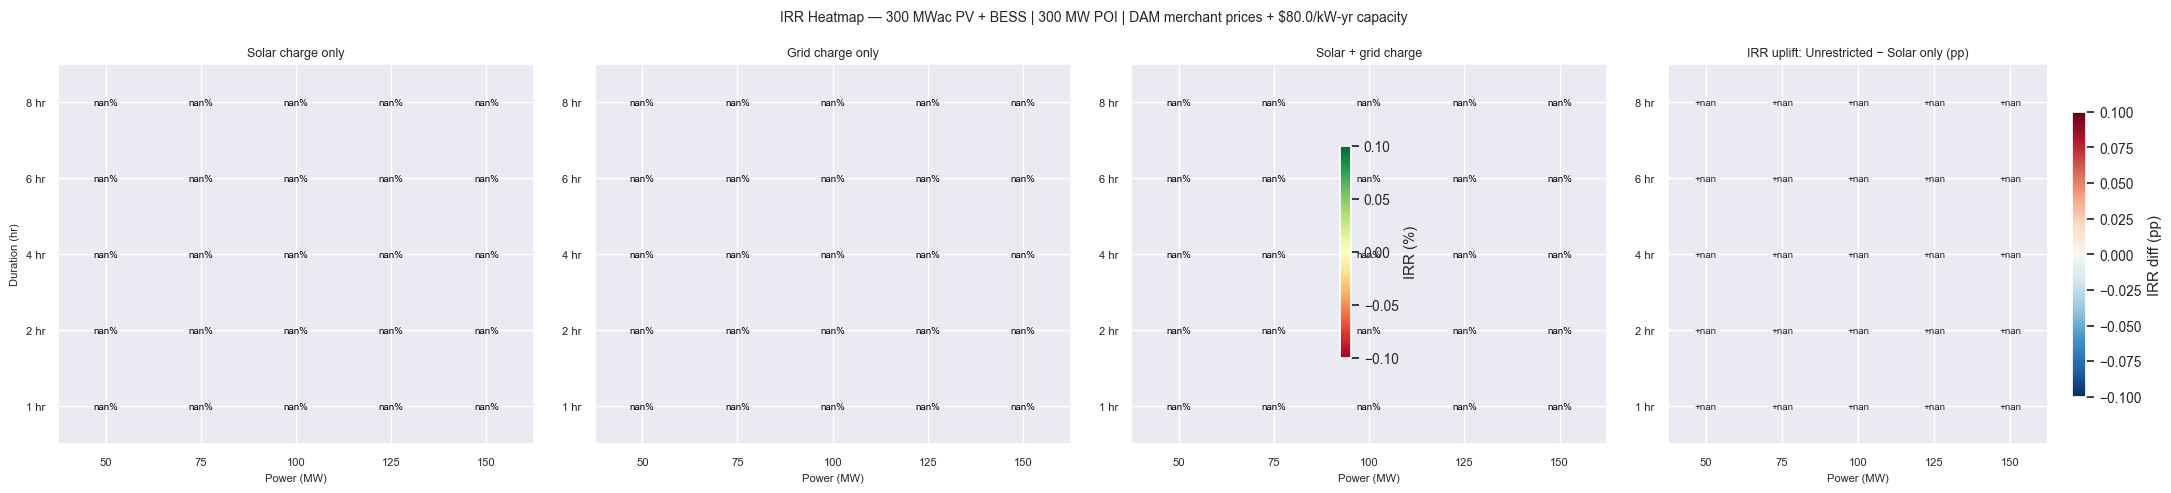

In [6]:
# ── Chart 1: IRR heatmap 4-panel ──────────────────────────────────────────────
modes_list = list(CHARGING_MODES.keys())
fig, axes  = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    f'IRR Heatmap — 300 MWac PV + BESS | {POI_LIMIT_KW/1000:.0f} MW POI | '
    f'DAM merchant prices + ${CAPACITY_PAYMENT_KW_YR}/kW-yr capacity',
    fontsize=10,
)

irr_matrices = {}
vmin = ts_results['irr_pct'].min()
vmax = ts_results['irr_pct'].max()

for col, mode in enumerate(modes_list):
    ax  = axes[col]
    sub = ts_results[ts_results['charging_mode'] == mode]
    mat = sub.pivot(index='duration_hr', columns='power_mw', values='irr_pct')
    mat = mat.loc[sorted(mat.index, reverse=True)]
    irr_matrices[mode] = mat

    im = ax.imshow(mat.values, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels([f'{int(c)}' for c in mat.columns], fontsize=8)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([f'{int(d)} hr' for d in mat.index], fontsize=8)
    ax.set_xlabel('Power (MW)', fontsize=8)
    ax.set_title(CHARGING_MODES[mode]['label'], fontsize=9)
    if col == 0:
        ax.set_ylabel('Duration (hr)', fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            c = 'white' if (v < vmin + (vmax-vmin)*0.25 or v > vmin + (vmax-vmin)*0.8) else 'black'
            ax.text(j, i, f'{v:.1f}%', ha='center', va='center', fontsize=7, color=c)

# Delta panel
ax    = axes[3]
delta = irr_matrices['unrestricted'].values - irr_matrices['solar_only'].values
lim   = max(abs(delta.min()), abs(delta.max()), 0.1)
im2   = ax.imshow(delta, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
ax.set_xticks(range(len(irr_matrices['unrestricted'].columns)))
ax.set_xticklabels([f'{int(c)}' for c in irr_matrices['unrestricted'].columns], fontsize=8)
ax.set_yticks(range(len(irr_matrices['unrestricted'].index)))
ax.set_yticklabels([f'{int(d)} hr' for d in irr_matrices['unrestricted'].index], fontsize=8)
ax.set_xlabel('Power (MW)', fontsize=8)
ax.set_title('IRR uplift: Unrestricted − Solar only (pp)', fontsize=9)
fig.colorbar(im2, ax=ax, shrink=0.75, label='IRR diff (pp)')
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        ax.text(j, i, f'{delta[i,j]:+.1f}', ha='center', va='center', fontsize=7)

fig.colorbar(im, ax=axes[:3].tolist(), shrink=0.55, label='IRR (%)', pad=0.01)
plt.tight_layout()
plt.savefig(_HERE / 'outputs' / 'surplus_irr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

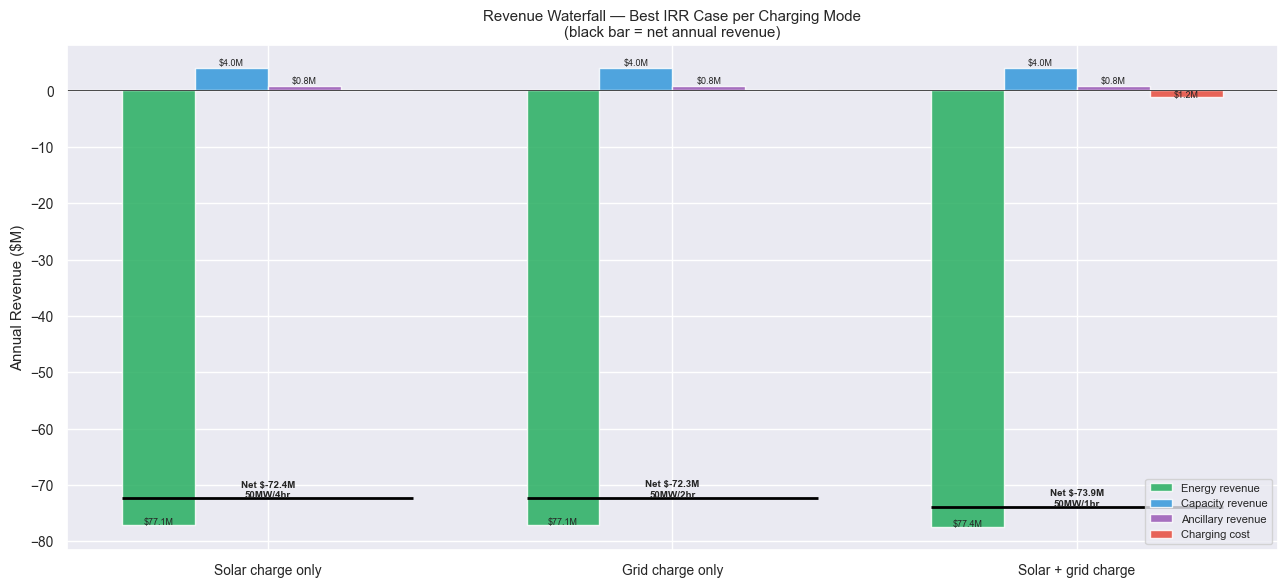

In [7]:
# ── Chart 2: Revenue waterfall — best IRR per mode ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
modes_list = list(CHARGING_MODES.keys())
col_map = {'energy_revenue_usd': '#27AE60', 'capacity_revenue_usd': '#3498DB',
           'ancillary_revenue_usd': '#9B59B6', 'charging_cost_usd': '#E74C3C'}
lbl_map = {'energy_revenue_usd': 'Energy revenue',
           'capacity_revenue_usd': 'Capacity revenue',
           'ancillary_revenue_usd': 'Ancillary revenue',
           'charging_cost_usd': 'Charging cost'}
offsets = {'energy_revenue_usd': -1.5, 'capacity_revenue_usd': -0.5,
           'ancillary_revenue_usd': 0.5, 'charging_cost_usd': 1.5}
w = 0.18
x = np.arange(len(modes_list))

for col_name, off in offsets.items():
    vals = []
    for mode in modes_list:
        row = ts_results[ts_results['charging_mode'] == mode].nlargest(1, 'irr_pct').iloc[0]
        vals.append(-row[col_name] / 1e6 if col_name == 'charging_cost_usd'
                    else row[col_name] / 1e6)
    bars = ax.bar(x + off * w, vals, w, color=col_map[col_name], alpha=0.85,
                  label=lbl_map[col_name])
    for bar, v in zip(bars, vals):
        if abs(v) > 0.1:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.1 if v >= 0 else -0.3),
                    f'${abs(v):.1f}M', ha='center', va='bottom', fontsize=6.5)

for i, mode in enumerate(modes_list):
    row   = ts_results[ts_results['charging_mode'] == mode].nlargest(1, 'irr_pct').iloc[0]
    net_m = row['net_annual_revenue_usd'] / 1e6
    pw, dr = int(row['power_mw']), int(row['duration_hr'])
    ax.hlines(net_m, i - 2*w, i + 2*w, colors='black', linewidth=2)
    ax.text(i, net_m + 0.15, f'Net ${net_m:.1f}M\n{pw}MW/{dr}hr',
            ha='center', fontsize=7, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([CHARGING_MODES[m]['label'] for m in modes_list])
ax.set_ylabel('Annual Revenue ($M)')
ax.set_title('Revenue Waterfall — Best IRR Case per Charging Mode\n'
             '(black bar = net annual revenue)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(_HERE / 'outputs' / 'surplus_revenue_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

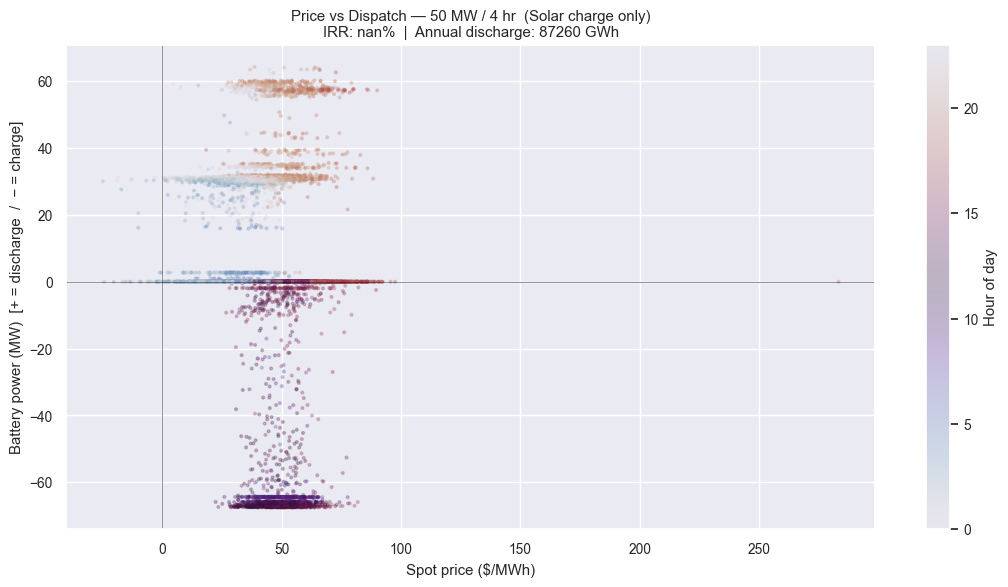

In [8]:
# ── Chart 3: Price vs dispatch scatter — best overall IRR ─────────────────────
best_row  = ts_results.nlargest(1, 'irr_pct').iloc[0]
best_key  = (best_row['power_mw'], best_row['duration_hr'], best_row['charging_mode'])
best_ts   = hourly_data[best_key]

hod = np.tile(np.arange(24), 365)
px  = np.array(hourly_prices)
py  = best_ts['batt_mw']

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(px, py, c=hod, cmap='twilight', alpha=0.25, s=4)
fig.colorbar(sc, ax=ax, label='Hour of day')
ax.axhline(0, color='black', linewidth=0.6, alpha=0.5)
ax.axvline(0, color='black', linewidth=0.6, alpha=0.5)
ax.set_xlabel('Spot price ($/MWh)')
ax.set_ylabel('Battery power (MW)  [+ = discharge  /  − = charge]')
ax.set_title(
    f'Price vs Dispatch — {int(best_row["power_mw"])} MW / '
    f'{int(best_row["duration_hr"])} hr  '
    f'({CHARGING_MODES[best_row["charging_mode"]]["label"]})\n'
    f'IRR: {best_row["irr_pct"]:.1f}%  |  '
    f'Annual discharge: {best_row["batt_annual_discharge_energy_kwh"]/1e3:.0f} GWh'
)
plt.tight_layout()
plt.savefig(_HERE / 'outputs' / 'surplus_price_dispatch.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Interactive Dashboard — Brownfield BESS Optimizer
# ═══════════════════════════════════════════════════════════════════════════════

# ── Controls Row 1: case selection ────────────────────────────────────────────
power_dd  = widgets.Dropdown(options=[50,75,100,125,150], value=50,
                              description='Power (MW):', style={'description_width':'initial'},
                              layout=widgets.Layout(width='180px'))
dur_dd    = widgets.Dropdown(options=[1,2,4,6,8], value=1,
                              description='Duration (hr):', style={'description_width':'initial'},
                              layout=widgets.Layout(width='185px'))
mode_rb   = widgets.RadioButtons(options=list(CHARGING_MODES.keys()),
                                  value='grid_only', description='Charging:',
                                  style={'description_width':'initial'})

# ── Controls Row 2: financial sliders ─────────────────────────────────────────
capex_sl  = widgets.IntSlider(value=250, min=150, max=400, step=10,
                               description='CAPEX $/kWh:', style={'description_width':'initial'},
                               layout=widgets.Layout(width='400px'))
cap_sl    = widgets.IntSlider(value=80, min=0, max=150, step=5,
                               description='Cap. payment $/kW-yr:', style={'description_width':'initial'},
                               layout=widgets.Layout(width='400px'))
disc_sl   = widgets.FloatSlider(value=8.0, min=5.0, max=12.0, step=0.5,
                                 description='Discount rate %:', style={'description_width':'initial'},
                                 layout=widgets.Layout(width='400px'))

# ── Controls Row 3: POI + price curve ────────────────────────────────────────
poi_sl    = widgets.IntSlider(value=90, min=50, max=100, step=5,
                               description='POI target %:', style={'description_width':'initial'},
                               layout=widgets.Layout(width='360px'))
week_sl   = widgets.IntSlider(value=27, min=1, max=52, step=1,
                               description='Week:', style={'description_width':'initial'},
                               layout=widgets.Layout(width='360px'))
price_rb  = widgets.RadioButtons(options=['Merchant', 'Flat $45', 'TOU peak/offpeak'],
                                  value='Merchant', description='Price curve:',
                                  style={'description_width':'initial'})

# ── Special buttons ──────────────────────────────────────────────────────────
btn_brkeven = widgets.Button(description='Find breakeven capacity payment',
                              button_style='info',
                              layout=widgets.Layout(width='280px'))
btn_pareto  = widgets.Button(description='Show Pareto frontier',
                              button_style='warning',
                              layout=widgets.Layout(width='200px'))
btn_export  = widgets.Button(description='Export filtered results',
                              button_style='success',
                              layout=widgets.Layout(width='200px'))

# ── Output widgets ────────────────────────────────────────────────────────────
main_out    = widgets.Output()
special_out = widgets.Output()


def _get_price_array():
    sel = price_rb.value
    if sel == 'Flat $45':
        return np.full(8760, 45.0)
    if sel == 'TOU peak/offpeak':
        hod = np.tile(np.arange(24), 365)
        # Weekday (approx): peak 7am-9pm = $65, off-peak = $25
        return np.where((hod >= 7) & (hod < 21), 65.0, 25.0)
    return np.array(hourly_prices)  # Merchant


def _redraw(change=None):
    pw   = power_dd.value
    dr   = dur_dd.value
    mode = mode_rb.value
    key  = (float(pw), float(dr), mode)
    if key not in hourly_data:
        with main_out:
            clear_output(wait=True)
            print(f'Case {pw} MW / {dr} hr / {mode} not in hourly_data.')
        return

    price_arr = _get_price_array()
    rec = _recalculate(
        key, price_arr,
        capex_kwh=capex_sl.value, cap_kw_yr=cap_sl.value,
        discount_pct=disc_sl.value, hourly_data=hourly_data,
    )

    with main_out:
        clear_output(wait=True)

        # ── 4-panel figure ─────────────────────────────────────────────────────
        fig = plt.figure(figsize=(20, 11))
        gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.30)

        # Panel 1: KPI HTML table (rendered via annotation in empty axes)
        ax_kpi = fig.add_subplot(gs[0, 0])
        ax_kpi.axis('off')
        kpi_lines = [
            ('Selected case',     f'{pw} MW / {dr} hr  ({pw*dr} MWh)'),
            ('Charging mode',      CHARGING_MODES[mode]['label']),
            ('Annual discharge',   f'{rec["annual_discharge_mwh"]:,.0f} MWh/yr'),
            ('Energy revenue',     f'${rec["energy_rev"]/1e6:.2f} M'),
            ('Capacity revenue',   f'${rec["cap_rev"]/1e6:.2f} M'),
            ('Charging cost',      f'${rec["charge_cost"]/1e6:.2f} M'),
            ('Net annual revenue', f'${rec["net_rev"]/1e6:.2f} M'),
            ('NPV',                f'${rec["npv"]/1e6:.1f} M'),
            ('IRR',                f'{rec["irr_pct"]:.2f} %'),
            ('LCOS',               f'${rec["lcos"]:.3f} /kWh'),
            ('POI utilization',    f'{rec["poi_util"]:.1f} %'),
            ('Avg daily cycles',   f'{rec["avg_daily_cycles"]:.2f}'),
        ]
        y0 = 0.97
        ax_kpi.text(0.02, y0 + 0.03, 'KPI Summary', fontsize=10, fontweight='bold',
                    transform=ax_kpi.transAxes)
        for lbl, val in kpi_lines:
            ax_kpi.text(0.02, y0, lbl + ':', fontsize=8.5, transform=ax_kpi.transAxes, color='#555')
            ax_kpi.text(0.65, y0, val,        fontsize=8.5, transform=ax_kpi.transAxes, fontweight='bold')
            y0 -= 0.078
        ax_kpi.set_facecolor('#F8F9FA')
        for spine in ax_kpi.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)

        # Panel 2: Dispatch stack — selected week
        ax_d = fig.add_subplot(gs[0, 1])
        wk   = week_sl.value
        sl   = slice((wk - 1) * 168, wk * 168)
        ts   = hourly_data[key]
        gen_w  = ts['gen_mw'][sl]
        batt_w = ts['batt_mw'][sl]
        soc_w  = ts['soc_pct'][sl]
        exp_w  = ts['export_mw'][sl]
        dt_w   = DT_IDX[sl]
        hrs    = np.arange(len(dt_w))
        pv_ac  = gen_w - np.maximum(batt_w, 0)
        b_dis  = np.maximum(batt_w, 0)
        b_chg  = np.minimum(batt_w, 0)
        ax_d.fill_between(hrs, 0, pv_ac,             color='#FFD700', alpha=0.85, label='PV gen')
        ax_d.fill_between(hrs, pv_ac, pv_ac + b_dis, color='#27AE60', alpha=0.75, label='BESS discharge')
        ax_d.fill_between(hrs, b_chg, 0,             color='#E74C3C', alpha=0.70, label='BESS charge')
        ax_d.plot(hrs, exp_w, color='#2C3E50', linewidth=1.3, label='Grid export', zorder=5)
        ax_d.axhline(POI_LIMIT_KW / 1000, color='purple', linestyle='--', linewidth=1.0,
                     alpha=0.6, label=f'POI {POI_LIMIT_KW/1000:.0f} MW')
        poi_target_mw = POI_LIMIT_KW / 1000 * poi_sl.value / 100
        ax_d.axhline(poi_target_mw, color='orange', linestyle=':', linewidth=1.0,
                     alpha=0.7, label=f'POI target {poi_sl.value}%')
        ax2d = ax_d.twinx()
        ax2d.plot(hrs, soc_w, color='grey', linestyle='--', linewidth=1.0, alpha=0.6)
        ax2d.set_ylim(0, 115)
        ax2d.set_ylabel('SOC (%)', color='grey', fontsize=7)
        ax2d.tick_params(axis='y', labelcolor='grey', labelsize=7)
        dticks = np.arange(0, len(hrs), 24)
        ax_d.set_xticks(dticks)
        ax_d.set_xticklabels([dt_w[i].strftime('%b %d') for i in dticks], fontsize=7)
        ax_d.set_title(f'Week {wk} Dispatch  ({dt_w[0].strftime("%b %d")} – {dt_w[-1].strftime("%b %d")})',
                       fontsize=9)
        ax_d.set_ylabel('Power (MW)', fontsize=8)
        ax_d.legend(fontsize=6, loc='upper right', ncol=3)

        # Panel 3: SOC heatmap (full year)
        ax_s = fig.add_subplot(gs[1, 0])
        soc_2d = ts['soc_pct'][:8760].reshape(365, 24).T
        im = ax_s.pcolormesh(np.arange(365), np.arange(24), soc_2d,
                             cmap='RdYlGn', vmin=0, vmax=100)
        fig.colorbar(im, ax=ax_s, label='SOC (%)', shrink=0.85, pad=0.01)
        for d in [31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]:
            ax_s.axvline(d, color='white', linewidth=0.5, alpha=0.5)
        ax_s.invert_yaxis()
        ax_s.set_xlabel('Day of Year')
        ax_s.set_ylabel('Hour of Day')
        ax_s.set_title('Full Year SOC Heatmap', fontsize=9)
        ax_s.set_yticks([0, 6, 12, 18, 23])
        ax_s.set_yticklabels(['00:00','06:00','12:00','18:00','23:00'], fontsize=7)

        # Panel 4: Price vs dispatch scatter
        ax_p = fig.add_subplot(gs[1, 1])
        hod  = np.tile(np.arange(24), 365)
        sc2  = ax_p.scatter(price_arr, ts['batt_mw'], c=hod, cmap='twilight',
                            alpha=0.20, s=3)
        fig.colorbar(sc2, ax=ax_p, label='Hour of day', shrink=0.85)
        ax_p.axhline(0, color='black', linewidth=0.6, alpha=0.5)
        ax_p.axvline(0, color='black', linewidth=0.6, alpha=0.5)
        ax_p.set_xlabel('Spot price ($/MWh)')
        ax_p.set_ylabel('Battery power (MW)')
        ax_p.set_title(f'Price vs Dispatch ({price_rb.value})', fontsize=9)

        fig.suptitle(
            f'Brownfield BESS: {pw} MW / {dr} hr  ({CHARGING_MODES[mode]["label"]})  '
            f'|  IRR: {rec["irr_pct"]:.1f}%  NPV: ${rec["npv"]/1e6:.1f}M',
            fontsize=11, fontweight='bold',
        )
        plt.show()


# ── Breakeven analysis ────────────────────────────────────────────────────────
def _on_breakeven(b):
    with special_out:
        clear_output(wait=True)
        pw, dr, mode = power_dd.value, dur_dd.value, mode_rb.value
        key = (float(pw), float(dr), mode)
        if key not in hourly_data:
            print('Case not available.')
            return
        price_arr = _get_price_array()
        breakeven_cp = None
        for cp in range(0, 155, 5):
            rec = _recalculate(key, price_arr, capex_kwh=capex_sl.value,
                               cap_kw_yr=cp, discount_pct=disc_sl.value,
                               hourly_data=hourly_data)
            if rec['npv'] >= 0:
                breakeven_cp = cp
                break
        if breakeven_cp is not None:
            print(f'Breakeven capacity payment: ${breakeven_cp}/kW-yr '
                  f'(NPV = ${rec["npv"]/1e6:.2f}M at ${breakeven_cp}/kW-yr)')
        else:
            print('NPV < 0 even at $150/kW-yr capacity payment with current assumptions.')


# ── Pareto frontier ───────────────────────────────────────────────────────────
def _on_pareto(b):
    with special_out:
        clear_output(wait=True)
        price_arr = _get_price_array()
        records = []
        for key in hourly_data:
            rec = _recalculate(key, price_arr, capex_kwh=capex_sl.value,
                               cap_kw_yr=cap_sl.value, discount_pct=disc_sl.value,
                               hourly_data=hourly_data)
            records.append({'power_mw': key[0], 'duration_hr': key[1],
                            'mode': key[2], 'energy_mwh': key[0]*key[1],
                            'irr': rec['irr_pct'], 'npv': rec['npv']})
        df_p = pd.DataFrame(records)

        # Pareto frontier (max IRR for given NPV range)
        pareto_idx = []
        for i, row in df_p.iterrows():
            dominated = any(
                (df_p.loc[j, 'npv'] >= row['npv']) and
                (df_p.loc[j, 'irr'] >= row['irr']) and
                (j != i)
                for j in df_p.index
            )
            if not dominated:
                pareto_idx.append(i)
        df_par = df_p.loc[pareto_idx].sort_values('npv')

        colors = {'solar_only': '#3498DB', 'grid_only': '#E74C3C', 'unrestricted': '#27AE60'}
        fig, ax = plt.subplots(figsize=(12, 7))
        for mode in CHARGING_MODES:
            sub = df_p[df_p['mode'] == mode]
            ax.scatter(sub['npv']/1e6, sub['irr'], c=colors[mode],
                       s=sub['energy_mwh'] / 50, alpha=0.6,
                       label=CHARGING_MODES[mode]['label'])
        ax.plot(df_par['npv']/1e6, df_par['irr'], 'k--', linewidth=1.5,
                label='Pareto frontier', zorder=5)
        ax.scatter(df_par['npv']/1e6, df_par['irr'], c='gold', s=80,
                   edgecolors='black', linewidth=0.8, zorder=6)
        ax.set_xlabel('NPV ($M)')
        ax.set_ylabel('IRR (%)')
        ax.set_title(f'Pareto Frontier — {price_rb.value} prices\n'
                     f'(bubble size = BESS energy MWh, gold = Pareto-optimal)')
        handles, lbls = ax.get_legend_handles_labels()
        ax.legend(handles, lbls, fontsize=8)
        plt.tight_layout()
        plt.show()


# ── Export ────────────────────────────────────────────────────────────────────
def _on_export(b):
    with special_out:
        clear_output(wait=True)
        price_arr = _get_price_array()
        rows_exp = []
        for key in hourly_data:
            rec = _recalculate(key, price_arr, capex_kwh=capex_sl.value,
                               cap_kw_yr=cap_sl.value, discount_pct=disc_sl.value,
                               hourly_data=hourly_data)
            rows_exp.append({'power_mw': key[0], 'duration_hr': key[1],
                             'charging_mode': key[2], **rec})
        df_exp = pd.DataFrame(rows_exp)
        out_path = _HERE / 'outputs' / 'bess_surplus_filtered_export.csv'
        df_exp.to_csv(out_path, index=False)
        print(f'Exported {len(df_exp)} rows → {out_path}')
        display(df_exp.nlargest(10, 'irr_pct')[
            ['power_mw','duration_hr','charging_mode','irr_pct','npv','lcos']
        ].round(3))


btn_brkeven.on_click(_on_breakeven)
btn_pareto.on_click(_on_pareto)
btn_export.on_click(_on_export)

# ── Observe all controls ──────────────────────────────────────────────────────
for ctrl in [power_dd, dur_dd, mode_rb, capex_sl, cap_sl, disc_sl,
             poi_sl, week_sl, price_rb]:
    ctrl.observe(_redraw, names='value')

# ── Layout ────────────────────────────────────────────────────────────────────
row1 = widgets.HBox([power_dd, dur_dd, mode_rb])
row2 = widgets.VBox([capex_sl, cap_sl, disc_sl])
row3 = widgets.HBox([widgets.VBox([poi_sl, week_sl]), price_rb])
btns = widgets.HBox([btn_brkeven, btn_pareto, btn_export])
ctrl_panel = widgets.VBox([
    widgets.HTML('<b>Case selection</b>'), row1,
    widgets.HTML('<b>Financial parameters (recalculate without re-simulation)</b>'), row2,
    widgets.HTML('<b>Dispatch view controls</b>'), row3,
    widgets.HTML('<b>Analysis tools</b>'), btns,
])

display(ctrl_panel)
display(main_out)
display(special_out)
_redraw()

Output()

Output()